Academic Data Shape: (500, 6)
Extra Data Shape: (500, 4)

Merged Dataset Shape: (500, 9)

--- Data Types ---
StudentID                      int64
Age                            int64
StudyHoursPerWeek              int64
AttendanceRate               float64
GPA                          float64
Major                         object
Gender                        object
PartTimeJob                   object
ExtraCurricularActivities     object
dtype: object

--- Descriptive Statistics ---
         StudentID         Age  StudyHoursPerWeek  AttendanceRate        GPA  \
count   500.000000  500.000000         500.000000      500.000000  500.00000   
unique         NaN         NaN                NaN             NaN        NaN   
top            NaN         NaN                NaN             NaN        NaN   
freq           NaN         NaN                NaN             NaN        NaN   
mean    250.500000   20.956000          19.876000       74.990380    2.98516   
std     144.481833    2.000517  

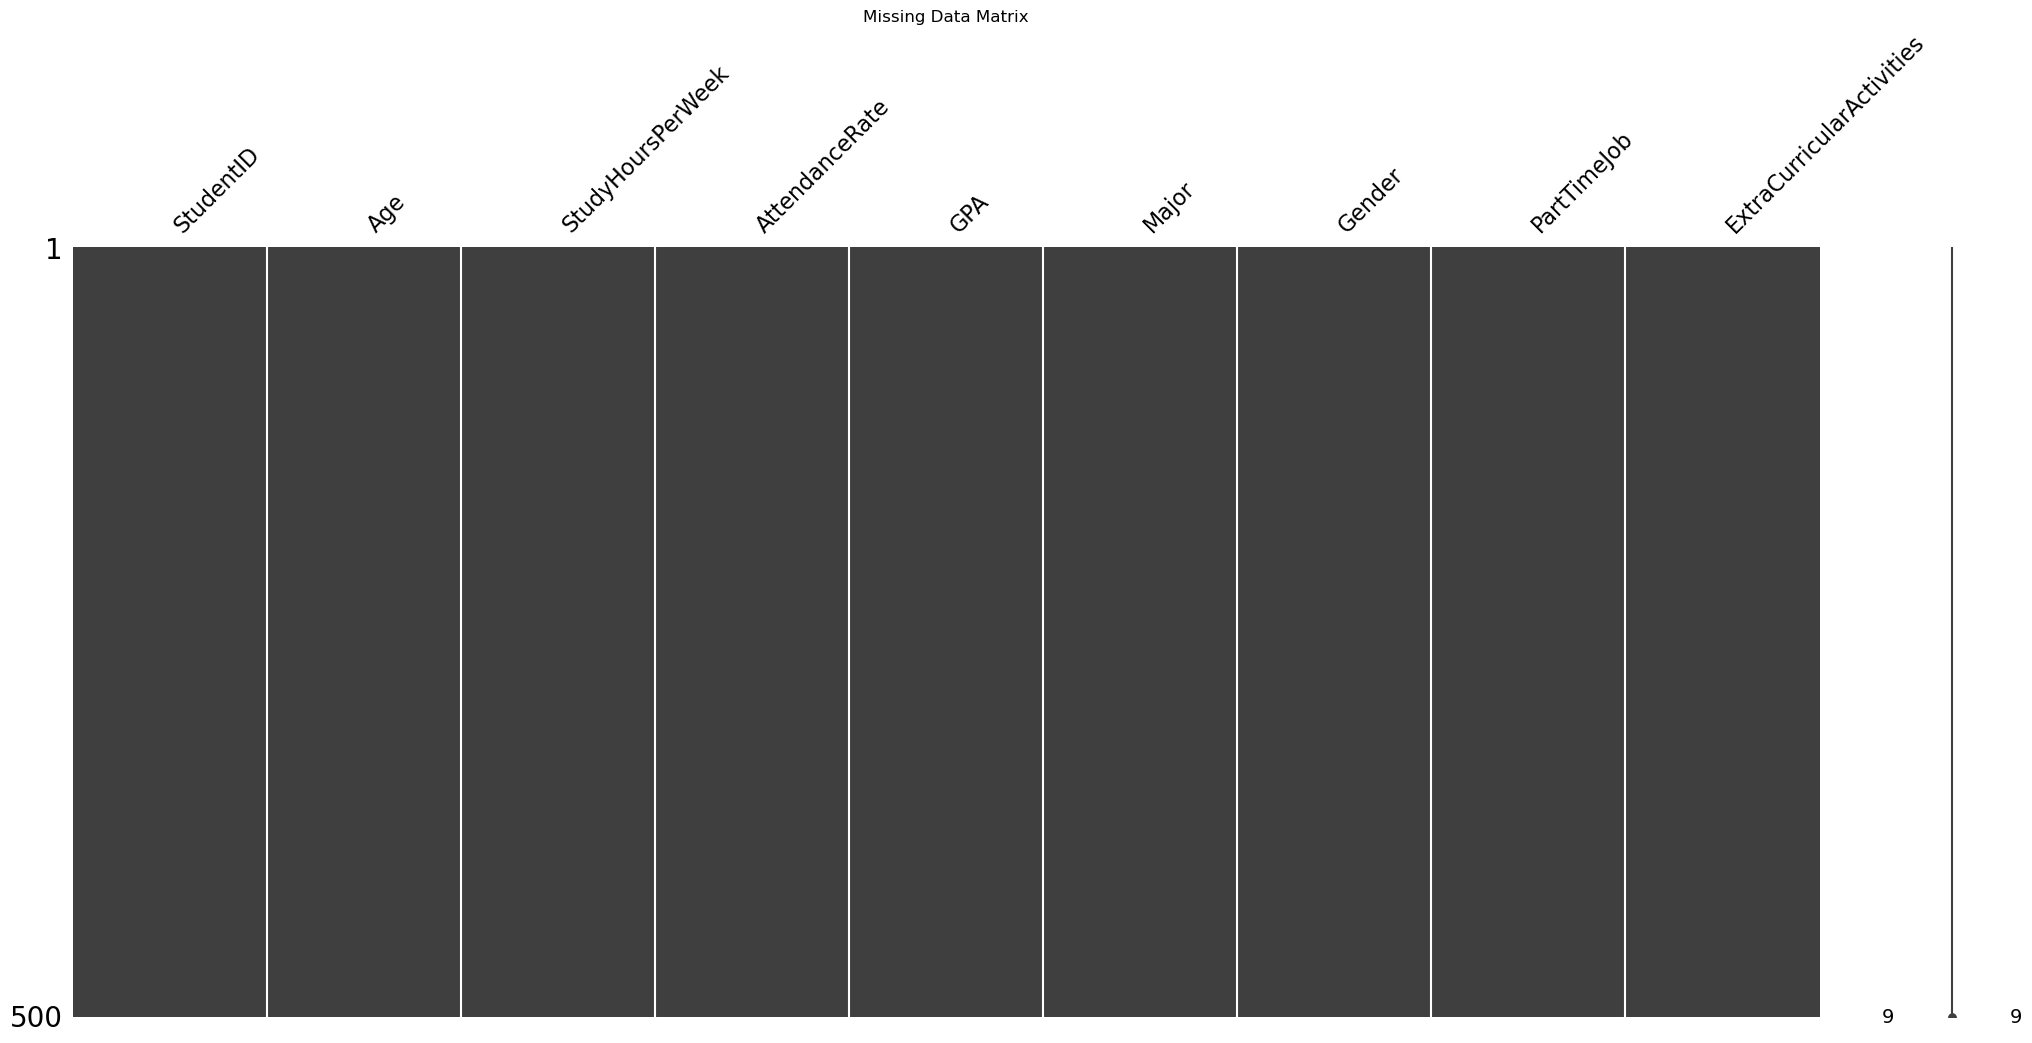

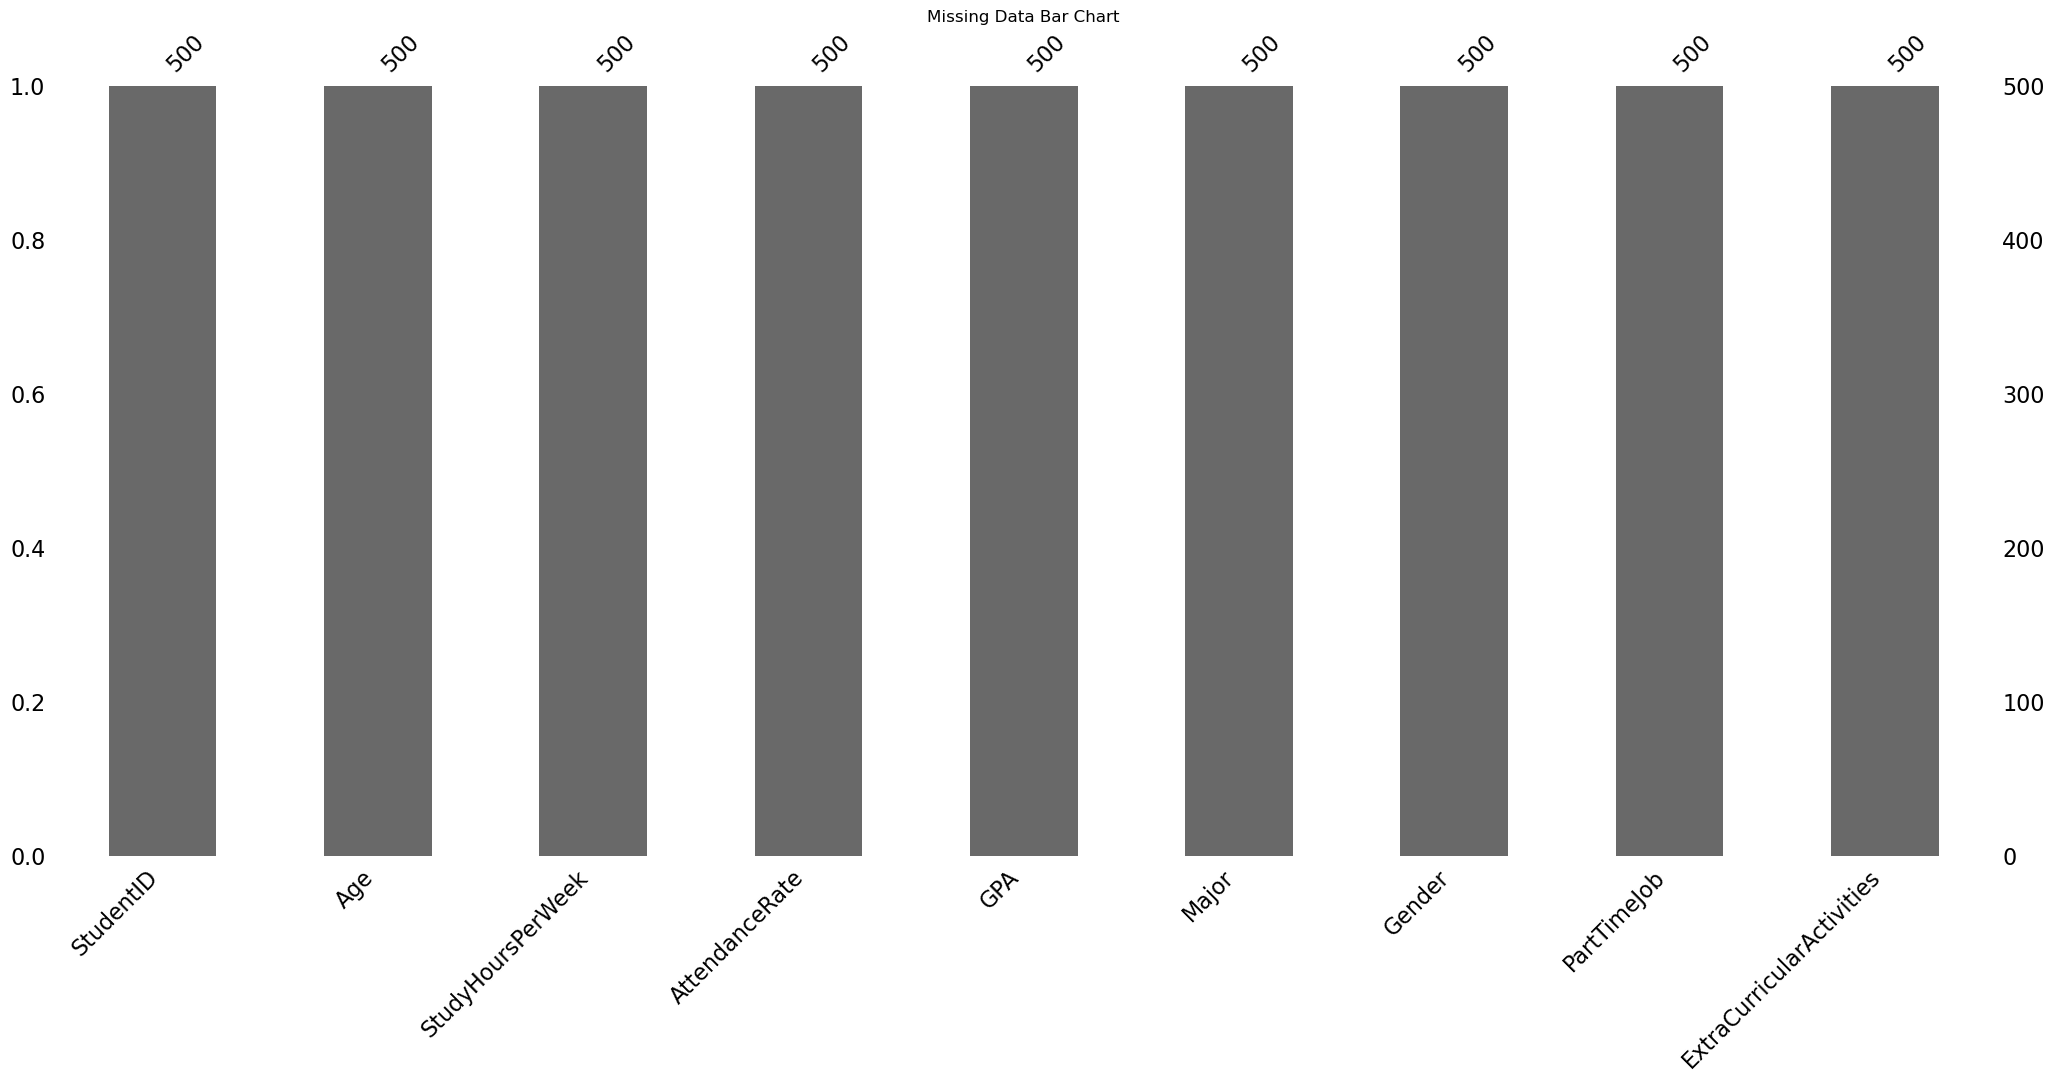


--- Categorical Distribution (%) ---

Major distribution:
Major
Business       22.8
Engineering    21.8
Arts           20.0
Education      19.4
Science        16.0
Name: proportion, dtype: float64

Gender distribution:
Gender
Female    51.2
Male      48.8
Name: proportion, dtype: float64

PartTimeJob distribution:
PartTimeJob
Yes    53.6
No     46.4
Name: proportion, dtype: float64

ExtraCurricularActivities distribution:
ExtraCurricularActivities
No     52.0
Yes    48.0
Name: proportion, dtype: float64

--- Correlation Matrix ---
                   StudentID       Age  StudyHoursPerWeek  AttendanceRate  \
StudentID           1.000000 -0.019205           0.017845       -0.033530   
Age                -0.019205  1.000000          -0.015695        0.037364   
StudyHoursPerWeek   0.017845 -0.015695           1.000000        0.095716   
AttendanceRate     -0.033530  0.037364           0.095716        1.000000   
GPA                -0.061763  0.095805           0.091700        0.060828   


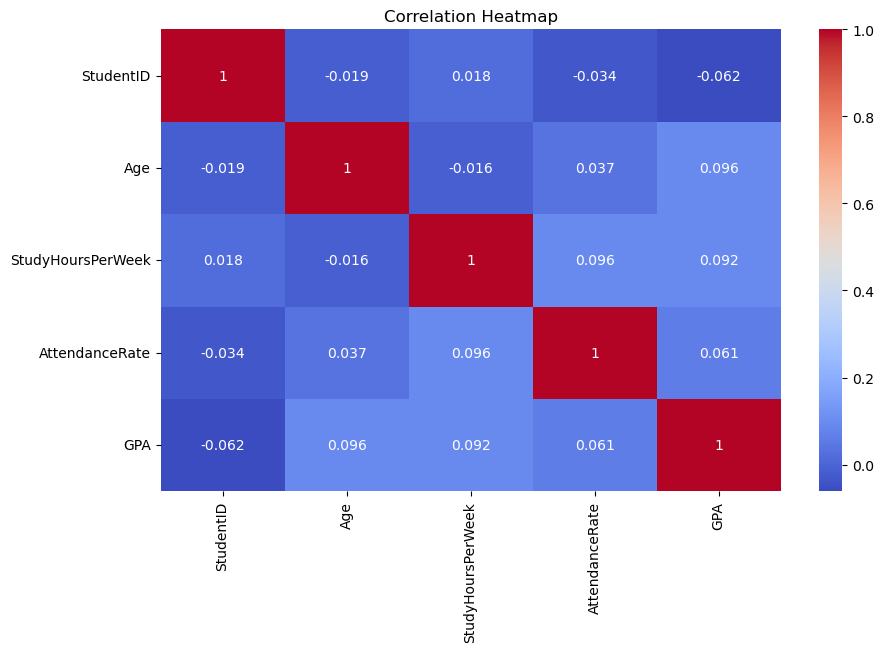


--- Basic Insights ---
Total Students: 500
Columns: ['StudentID', 'Age', 'StudyHoursPerWeek', 'AttendanceRate', 'GPA', 'Major', 'Gender', 'PartTimeJob', 'ExtraCurricularActivities']


In [7]:
#  Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#  Load Datasets

df_academic = pd.read_csv('academic_data.csv')
df_extra = pd.read_json('extra_student_data.json')

print("Academic Data Shape:", df_academic.shape)
print("Extra Data Shape:", df_extra.shape)

#  Merge Datasets (Heterogeneous Integration)
df = pd.merge(df_academic, df_extra, on='StudentID', how='inner')

print("\nMerged Dataset Shape:", df.shape)

# Inspect Data Types & Summary

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

#  Missing & Unique Values

print("\n--- Missing Values (%) ---")
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

print("\n--- Unique Values (Categorical Columns) ---")
for col in df.select_dtypes(include='object'):
    print(f"\n{col} unique values:")
    print(df[col].unique())


# STEP 3: Data from Multiple Sources (Already Done Above)
# Explanation:
# df_academic (CSV) + df_extra (JSON) merged using StudentID


# STEP 4: Visualize Missing Data

print("\n--- Missing Data Visualization ---")

msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

msno.bar(df)
plt.title("Missing Data Bar Chart")
plt.show()

# STEP 5: Summary Statistics & Characterization

# Categorical Distribution
print("\n--- Categorical Distribution (%) ---")
for col in df.select_dtypes(include='object'):
    print(f"\n{col} distribution:")
    print(df[col].value_counts(normalize=True) * 100)

# Correlation Matrix (Numerical Columns)
print("\n--- Correlation Matrix ---")
corr = df.corr(numeric_only=True)
print(corr)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# FINAL INSIGHTS (Optional Print)
print("\n--- Basic Insights ---")
print("Total Students:", df.shape[0])
print("Columns:", df.columns.tolist())